![](https://github.com/destination-earth/DestinE-DataLake-Lab/blob/main/img/DestinE-banner.jpg?raw=true)

# Extraction of ClimateDT data
Data portfolio: https://confluence.ecmwf.int/display/DDCZ/Climate+DT+Phase+1+data+catalogue#ClimateDTPhase1datacatalogue-Fieldsonasinglelevelorsurface

### Connect to polytope

In [ ]:
%%capture cap
%run ./src/desp-authentication.py

In [2]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]
access_token

'Token successfully written to /home/koenifra/.polytopeapirc'

In [3]:
import pandas as pd
import concurrent.futures
import xarray as xr
import os

### Load csv

In [4]:
geosphere_stations = pd.read_csv("./points/points_IFS_NEMO_ScenarioMIP_141.csv")
# geosphere_stations = pd.read_csv("./location_hourly_daily_stations_2007_2025.csv")
# geosphere_stations["latitude"]=geosphere_stations["Lat"]
# geosphere_stations["longitude"]=geosphere_stations["Lon"]

geosphere_stations

,datetimes,number,steps,points,sd,latitude,longitude,levelist
0,2022-01-01 00:00:00Z,0,0,0,0.000000,43.008634,4.005000,0.0
1,2022-01-01 00:00:00Z,0,0,1,0.000000,43.008634,4.095000,0.0
2,2022-01-01 00:00:00Z,0,0,2,0.000000,43.008634,4.185000,0.0
3,2022-01-01 00:00:00Z,0,0,3,0.000000,43.008634,4.275000,0.0
4,2022-01-01 00:00:00Z,0,0,4,0.000000,43.008634,4.365000,0.0
...,...,...,...,...,...,...,...,...
20663,2022-01-01 00:00:00Z,0,0,20663,0.002783,49.994235,17.569930,0.0
20664,2022-01-01 00:00:00Z,0,0,20664,0.000744,49.994235,17.674825,0.0
20665,2022-01-01 00:00:00Z,0,0,20665,0.000153,49.994235,17.779720,0.0
20666,2022-01-01 00:00:00Z,0,0,20666,0.000054,49.994235,17.884615,0.0


In [5]:
scenarios = pd.read_csv("./climate-dt-scenarios.csv", sep=";")
scenarios

,params,model,level type,experiment,resolution,temporal extent,activity,typeOfSimulation
0,167/260048,ICON,sfc,hist,high,1990-2024,CMIP6,NaN
1,141/167/228/260048,IFS-NEMO,sfc,hist,high,1990-2024,CMIP6,NaN
2,228141,IFS-NEMO,sol,hist,high,1990-2024,CMIP6,NaN
3,167/228,IFS-FESOM,sfc,cont,high,1990-2004,HighResMIP,Control simulation
4,167/228,IFS-NEMO,sfc,cont,high,1990-2007,HighResMIP,Control simulation
5,167/260048,ICON,sfc,SSP3-7.0,high,2020-2039,ScenarioMIP,Future projection
6,167/228,IFS-FESOM,sfc,SSP3-7.0,high,2020-2039,ScenarioMIP,Future projection
7,141/167/228/260048,IFS-NEMO,sfc,SSP3-7.0,high,2020-2039,ScenarioMIP,Future projection
8,228141,IFS-NEMO,sol,SSP3-7.0,high,2020-2050,ScenarioMIP,NaN
9,167/228,IFS-FESOM,sfc,cont,high,2017-2023,story-nudging,Storyline simulation


**The following dependencies are missing in the current kernel**

In [6]:
# pip install -q polytope-client covjsonkit

In [7]:
from typing import Literal
def extract_cdt_ts(experiment: str,
                   activity: str,
                   level_type: str,
                   datestring: str,
                   model: str,
                   parameter: str,
                   location: list,
                   feature: Literal["timeseries", "polygon"]="timeseries",
                   time_resolution: str="0000/to/2300",
                   resolution: str="high"):
    import earthkit.data
    
    if feature == "timeseries":
        feature_dict = {
            "type" : "timeseries",
            "points": location,
            "time_axis": "date"
        }
    elif feature == "polygon":
        feature_dict = {
            "type" : "polygon",
            "shape": location
        }
    else:
        raise TypeError("feature not supported")
    
    request = {
        # static parameters of climate dt data
        "class": "d1",
        "dataset": "climate-dt",
        "generation": "1",
        "expver": "0001",
        "stream": "clte",
        "type": "fc",
        # generic
        "activity": activity,
        "experiment": experiment,
        "levtype": level_type,
        "date": datestring,
        "model": model,
        "param": parameter,
        # "param": "167/228",
        "param": "141",
        "realization": "1",
        "resolution": resolution,
        "time": time_resolution,
        "feature": feature_dict
    }

    # commented out to check if only one level is request it gets faster or not
    if level_type == "sol":
        # request["levelist"] = "1/to/5"
        request["levelist"] = "1"
    
    try:
        ds = earthkit.data.from_source("polytope", 
                                       "destination-earth", 
                                       request, stream=False, 
                                       address='polytope.lumi.apps.dte.destination-earth.eu')
        return ds.to_xarray()
    except Exception as e:
        print(e)
        return None
    # return ds.to_xarray()
    
    

In [8]:
def get_datestring(temp_extent: str):
    '''
    Example output string "20200101/to/20210101"
    '''
    years = temp_extent.split("-")
    return f"{years[0]}0101/to/{years[1]}1231"
    

## Extract TS per Geosphere Station and scenario

In [9]:
experiment="SSP3-7.0"
activity="ScenarioMIP"
level_type="sfc"
datestring=get_datestring("2020-2024")
model="IFS-NEMO"
parameter="141"

In [10]:
# def get_station_data(geosphere_station, scenario):
#     # convert georeference
#     latlon = [[float(geosphere_station["latitude"]),float(geosphere_station["longitude"])]]

#     # get time series of station
#     ts = extract_cdt_ts(scenario["experiment"],
#                         scenario["activity"],
#                         scenario["level type"],
#                         get_datestring(scenario["temporal extent"]),
#                         scenario["model"],
#                         scenario["params"],
#                         latlon)
#     return ts.assign_coords({"pointid": geosphere_station["points"]}) \
#         .expand_dims(dim="pointid")

def get_station_data(geosphere_station, scenario):
    latlon = [[float(geosphere_station["latitude"]), float(geosphere_station["longitude"])]]

    ts = extract_cdt_ts(
        experiment=scenario["experiment"],
        activity=scenario["activity"],
        level_type=scenario["level type"],
        datestring=get_datestring(scenario["temporal extent"]),
        model=scenario["model"],
        parameter=scenario["params"],
        location=latlon
    )

    if ts is None:
        return None

    point_id = int(geosphere_station["points"])

    return ts.stack(pointid=("latitude", "longitude")) \
             .reset_index("pointid") \
             .assign_coords({"stationid": ("pointid", [geosphere_station["points"]])}) \
             .assign_coords({"pointid": [point_id]}) \
             .transpose("pointid", ...)

In [11]:
scenario = scenarios.iloc[12]

scenario_ts = xr.Dataset()

scenario

params                            141
model                        IFS-NEMO
level type                        sfc
experiment                   SSP3-7.0
resolution                       high
temporal extent             2020-2024
activity                  ScenarioMIP
typeOfSimulation    Future projection
Name: 12, dtype: object

In [12]:
print(scenario["temporal extent"])
print(get_datestring(scenario["temporal extent"]))
print(get_datestring("2020-2024"))

2020-2024
20200101/to/20241231
20200101/to/20241231


In [14]:
store_path = f"../dt_climate-zarr-save/{scenario['model']}_{scenario['level type']}_{scenario['activity']}_{scenario['experiment']}testi.zarr"
# store_path = f"{scenario['model']}_{scenario['level type']}_{scenario['activity']}_SSP3-7.zarr"
print(f"Data will be stored in: {store_path}")

Data will be stored in: ../dt_climate-zarr-save/IFS-NEMO_sfc_ScenarioMIP_SSP3-7.0testi.zarr


In [19]:
# test = get_station_data(geosphere_stations.iloc[0], scenario)
# print(test)
# print(test.dims)

In [ ]:
with concurrent.futures.ThreadPoolExecutor(max_workers=25) as executor:
    futures = []
    for ind, station in geosphere_stations.iloc[30:100].iterrows():
        futures.append(executor.submit(get_station_data, geosphere_station=station, scenario=scenario))
    
    for future in concurrent.futures.as_completed(futures):
        result = future.result()
        if result is None:
            print("Skipping failed station")
            continue
        if not os.path.exists(store_path):
            result.chunk(chunks={
                "pointid": 1,
                "levelist": 1,
                "number": 1,
                "datetime": 1,
                "t": "auto"
            }).to_zarr(store=store_path, mode="w")
        else:
            result.chunk(chunks={
                "pointid": 1,
                "levelist": 1,
                "number": 1,
                "datetime": 1,
                "t": "auto"
            }).to_zarr(store=store_path, append_dim="pointid")

2026-05-04 10:13:35 - INFO - Key read from /home/koenifra/.polytopeapirc
2026-05-04 10:13:35 - INFO - Key read from /home/koenifra/.polytopeapirc
2026-05-04 10:13:35 - INFO - Key read from /home/koenifra/.polytopeapirc
2026-05-04 10:13:35 - INFO - Sending request...
{'request': 'activity: ScenarioMIP\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20200101/to/20241231\n'
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 43.008633994237\n'
            '    - 6.705\n'
            '  time_axis: date\n'
            '  type: timeseries\n'
            "generation: '1'\n"
            'levtype: sfc\n'
            'model: IFS-NEMO\n'
            "param: '141'\n"
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            'time: 0000/to/2300\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-05-04 10:13:35 - INFO - Key read

In [18]:
import time

def get_station_data_with_retry(geosphere_station, scenario, max_retries=5, wait=30):
    for attempt in range(max_retries):
        try:
            result = get_station_data(geosphere_station, scenario)
            if result is not None:
                return result
        except Exception as e:
            print(f"Attempt {attempt + 1}/{max_retries} failed for station {geosphere_station['points']}: {e}")
        print(f"Waiting {wait}s before retry...")
        time.sleep(wait)
    print(f"All retries exhausted for station {geosphere_station['points']}")
    return None


with concurrent.futures.ThreadPoolExecutor(max_workers=25) as executor:
    futures = {}
    for ind, station in geosphere_stations.iterrows():
        future = executor.submit(get_station_data_with_retry, geosphere_station=station, scenario=scenario)
        futures[future] = station  # keep track of which station each future belongs to

    failed_stations = []

    for future in concurrent.futures.as_completed(futures):
        result = future.result()
        if result is None:
            failed_stations.append(futures[future])
            print(f"Station {futures[future]['points']} permanently failed, will retry later")
            continue
        if not os.path.exists(store_path):
            result.chunk(chunks={
                "pointid": 1,
                "levelist": 1,
                "number": 1,
                "datetime": 1,
                "t": "auto"
            }).to_zarr(store=store_path, mode="w")
        else:
            result.chunk(chunks={
                "pointid": 1,
                "levelist": 1,
                "number": 1,
                "datetime": 1,
                "t": "auto"
            }).to_zarr(store=store_path, append_dim="pointid")

# Retry permanently failed stations sequentially with longer waits
if failed_stations:
    print(f"\nRetrying {len(failed_stations)} permanently failed stations...")
    for station in failed_stations:
        result = get_station_data_with_retry(station, scenario, max_retries=10, wait=60)
        if result is not None:
            result.chunk(chunks={
                "pointid": 1,
                "levelist": 1,
                "number": 1,
                "datetime": 1,
                "t": "auto"
            }).to_zarr(store=store_path, append_dim="pointid")
        else:
            print(f"Station {station['points']} could not be retrieved after all retries")

2026-04-29 11:30:55 - INFO - Key read from /home/koenifra/.polytopeapirc
2026-04-29 11:30:55 - INFO - Key read from /home/koenifra/.polytopeapirc
2026-04-29 11:30:55 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20170101/to/20231231\n'
            'experiment: cont\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 48.01278\n'
            '    - 16.845\n'
            '  time_axis: date\n'
            '  type: timeseries\n'
            "generation: '1'\n"
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: 167/228\n'
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            'time: 0000/to/2300\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-04-29 11:30:55 - INFO - Key read from /home/koenifra/.polytopeapirc
2026-04-29 11:30:55 - INFO - Polytope user

Polytope error
Situation: trying to download data
Description: HTTP CLIENT ERROR (400)
URL: https://polytope.lumi.apps.dte.destination-earth.eu:443/api/v1/requests/0f0050c4-b27d-409e-8869-265440badbce
HTTP method: GET
Request header/body contents:
{'headers': {'Authorization': 'Bearer **********8RJg'}, 'json': None}
Expected responses: 200, 202
Received response: CLIENT ERROR (400)
Details:
Request failed with error:
Matched datasource polytope-climate

An error occurred (InternalError) when calling the UploadPart operation (reached max retries: 4): We encountered an internal error, please try again.
Waiting 30s before retry...
Polytope error
Situation: trying to download data
Description: HTTP CLIENT ERROR (400)
URL: https://polytope.lumi.apps.dte.destination-earth.eu:443/api/v1/requests/d14cfb77-551c-462a-a614-0659e1236beb
HTTP method: GET
Request header/body contents:
{'headers': {'Authorization': 'Bearer **********8RJg'}, 'json': None}
Expected responses: 200, 202
Received response

2026-04-29 11:33:18 - INFO - The current status of the request is 'processing'
2026-04-29 11:33:47 - INFO - Key read from /home/koenifra/.polytopeapirc
2026-04-29 11:33:47 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20170101/to/20231231\n'
            'experiment: cont\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 47.40833\n'
            '    - 16.26139\n'
            '  time_axis: date\n'
            '  type: timeseries\n'
            "generation: '1'\n"
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: 167/228\n'
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            'time: 0000/to/2300\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-04-29 11:33:47 - INFO - Polytope user key found in session cache for user koenifra
2026-04-29 11:33:47

Polytope error
Situation: trying to download data
Description: HTTP CLIENT ERROR (400)
URL: https://polytope.lumi.apps.dte.destination-earth.eu:443/api/v1/requests/f9d8194b-1810-4955-9e08-f144e3258079
HTTP method: GET
Request header/body contents:
{'headers': {'Authorization': 'Bearer **********8RJg'}, 'json': None}
Expected responses: 200, 202
Received response: CLIENT ERROR (400)
Details:
Request failed with error:
Matched datasource polytope-climate

An error occurred (InternalError) when calling the UploadPart operation (reached max retries: 4): We encountered an internal error, please try again.
Waiting 30s before retry...


2026-04-29 11:34:34 - INFO - Key read from /home/koenifra/.polytopeapirc
2026-04-29 11:34:34 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20170101/to/20231231\n'
            'experiment: cont\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 46.74189\n'
            '    - 13.08286\n'
            '  time_axis: date\n'
            '  type: timeseries\n'
            "generation: '1'\n"
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: 167/228\n'
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            'time: 0000/to/2300\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-04-29 11:34:34 - INFO - Polytope user key found in session cache for user koenifra
2026-04-29 11:34:35 - INFO - Request accepted. Please poll ./1c338341-1fad-4c85-9d3b-f8f345358ef1 

...

2026-04-29 11:38:09 - INFO - The current status of the request is 'processing'
2026-04-29 11:38:11 - INFO - The current status of the request is 'processed'
2026-04-29 11:38:12 - INFO - Key read from /home/koenifra/.polytopeapirc                          
2026-04-29 11:38:12 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20170101/to/20231231\n'
            'experiment: cont\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 48.19975\n'
            '    - 16.55917\n'
            '  time_axis: date\n'
            '  type: timeseries\n'
            "generation: '1'\n"
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: 167/228\n'
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            'time: 0000/to/2300\n'
            'type: fc\n',
 'verb': 'retrieve'}
202

Polytope error
Situation: trying to download data
Description: HTTP CLIENT ERROR (400)
URL: https://polytope.lumi.apps.dte.destination-earth.eu:443/api/v1/requests/5cc95b6a-ae41-42d4-b944-8ec29060fdba
HTTP method: GET
Request header/body contents:
{'headers': {'Authorization': 'Bearer **********8RJg'}, 'json': None}
Expected responses: 200, 202
Received response: CLIENT ERROR (400)
Details:
Request failed with error:
Matched datasource polytope-climate

An error occurred (InternalError) when calling the UploadPart operation (reached max retries: 4): We encountered an internal error, please try again.
Waiting 30s before retry...


2026-04-29 11:38:56 - INFO - The current status of the request is 'processing'
2026-04-29 11:39:02 - INFO - The current status of the request is 'processed'
2026-04-29 11:39:04 - INFO - Key read from /home/koenifra/.polytopeapirc                          
2026-04-29 11:39:04 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20170101/to/20231231\n'
            'experiment: cont\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 47.594444\n'
            '    - 14.738055\n'
            '  time_axis: date\n'
            '  type: timeseries\n'
            "generation: '1'\n"
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: 167/228\n'
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            'time: 0000/to/2300\n'
            'type: fc\n',
 'verb': 'retrieve'}
2

KeyboardInterrupt: 

2026-04-29 11:39:28 - INFO - The current status of the request is 'processing'


In [79]:
with concurrent.futures.ThreadPoolExecutor(max_workers=25) as executor:
    futures = []
    for ind, station in geosphere_stations.iloc[:5].iterrows():
    #for station in station_list:
        futures.append(executor.submit(get_station_data, geosphere_station=station, scenario=scenario))
    
    for future in concurrent.futures.as_completed(futures):
        if not os.path.exists(store_path):
            #scenario_ts = future.result().copy()
            future.result().chunk(chunks={"pointid": 1,
                            #   "latitude": 1,
                            #   "longitude": 1,
                              "levelist": 1,
                              "number": 1,
                              "datetime": 1,
                              "t": "auto"
                             }).to_zarr(store=store_path,
                        mode="w")
        else:
            #scenario_ts = xr.concat([scenario_ts, future.result()], dim="stationid")
            future.result().chunk(chunks={"pointid": 1,
                            #   "latitude": 1,
                            #   "longitude": 1,
                              "levelist": 1,
                              "number": 1,
                              "datetime": 1,
                              "t": "auto"
                             }).to_zarr(store=store_path,
                        append_dim="pointid")

2026-04-29 11:05:57 - INFO - Key read from /home/koenifra/.polytopeapirc
2026-04-29 11:05:57 - INFO - Sending request...
{'request': 'activity: ScenarioMIP\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20200101/to/20241231\n'
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 43.008633994237\n'
            '    - 4.005\n'
            '  time_axis: date\n'
            '  type: timeseries\n'
            "generation: '1'\n"
            'levtype: sfc\n'
            'model: IFS-NEMO\n'
            "param: '141'\n"
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            'time: 0000/to/2300\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-04-29 11:05:57 - INFO - Key read from /home/koenifra/.polytopeapirc
2026-04-29 11:05:57 - INFO - Key read from /home/koenifra/.polytopeapirc
2026-04-29 11:05:57 - INFO - Polytope

Polytope error
Situation: trying to download data
Description: HTTP CLIENT ERROR (400)
URL: https://polytope.lumi.apps.dte.destination-earth.eu:443/api/v1/requests/08d359a0-1e2d-4bee-8377-08fc8bd75f97
HTTP method: GET
Request header/body contents:
{'headers': {'Authorization': 'Bearer **********QNTg'}, 'json': None}
Expected responses: 200, 202
Received response: CLIENT ERROR (400)
Details:
Request failed with error:
Matched datasource polytope-climate

An error occurred (InternalError) when calling the UploadPart operation (reached max retries: 4): We encountered an internal error, please try again.


2026-04-29 11:07:18 - INFO - The current status of the request is 'processed'


AttributeError: 'NoneType' object has no attribute 'chunk'

### Open zarr store

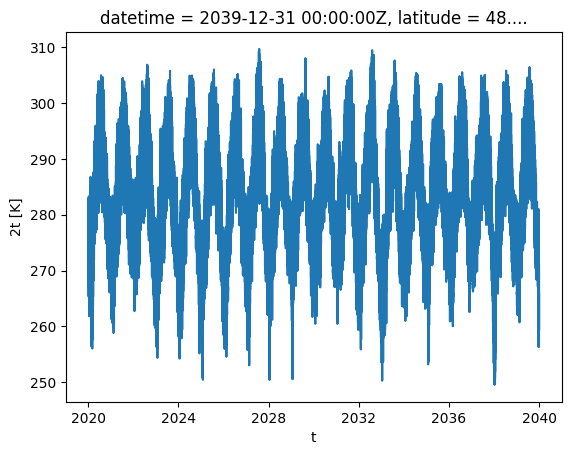

In [15]:
# zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-NEMO-CMIP6-hist", chunks="auto")
zstore_timedim = xr.open_zarr(store_path, chunks="auto",)

zstore_timedim["2t"].isel(pointid=79).plot()

In [16]:
s3_endpoint = "https://objects.eodc.eu"
bucket = "68e13833a1624f43ba2cac01376a18af:destine-climate-dt"
zarr_store = "climate-dt.zarr"

url = f"{s3_endpoint}/{bucket}/{zarr_store}"

# print(url)
dt = xr.open_datatree(url, engine="zarr", zarr_version = 3)
print(dt)

/tmp/ipykernel_10872/2090808177.py:8: FutureWarning: zarr_version is deprecated, use zarr_format
  dt = xr.open_datatree(url, engine="zarr", zarr_version = 3)


<xarray.DataTree>
Group: /
├── Group: /IFS-FESOM-story-nudging-cont
│       Dimensions:    (datetimes: 438288, points: 629)
│       Coordinates:
│         * datetimes  (datetimes) datetime64[ns] 4MB 1990-01-01 ... 2039-12-31T23:00:00
│         * points     (points) int64 5kB 0 1 2 3 4 5 6 ... 622 623 624 625 626 627 628
│           latitude   (points) float64 5kB ...
│           longitude  (points) float64 5kB ...
│       Data variables:
│           2t         (datetimes, points) float64 2GB ...
│           tp         (datetimes, points) float64 2GB ...
├── Group: /IFS-FESOM-story-nudging-hist
│       Dimensions:    (datetimes: 438288, points: 629)
│       Coordinates:
│         * datetimes  (datetimes) datetime64[ns] 4MB 1990-01-01 ... 2039-12-31T23:00:00
│         * points     (points) int64 5kB 0 1 2 3 4 5 6 ... 622 623 624 625 626 627 628
│           latitude   (points) float64 5kB ...
│           longitude  (points) float64 5kB ...
│       Data variables:
│           2t         (d

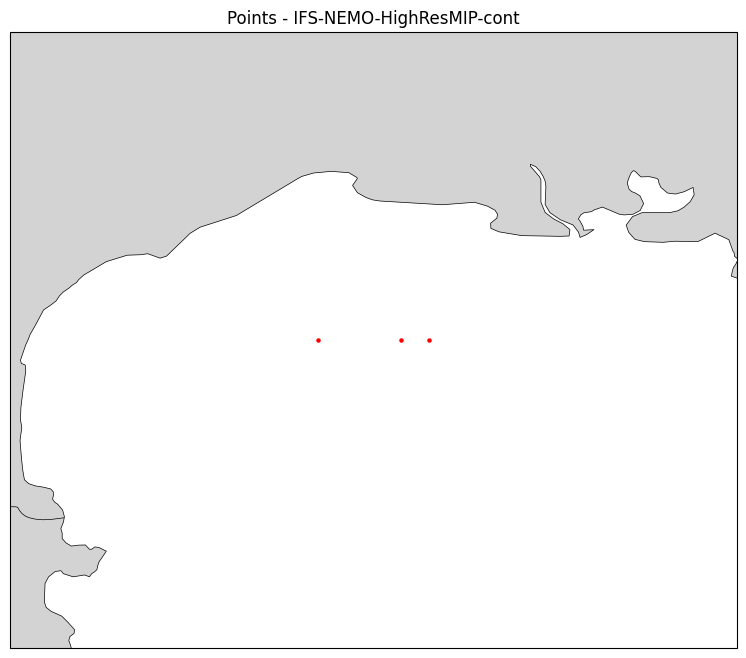

In [80]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

ds = xr.open_zarr("../dt_climate-zarr-save/IFS-NEMO_sfc_ScenarioMIP_SSP3-7.0testiiii.zarr/", chunks="auto",)
lats = ds.latitude.values
lons = ds.longitude.values

fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

ax.scatter(
    lons, lats,
    transform=ccrs.PlateCarree(),
    s=5, color="red", zorder=5
)

ax.set_extent([lons.min()-1, lons.max()+1, lats.min()-1, lats.max()+1])
plt.title("Points - IFS-NEMO-HighResMIP-cont")
plt.show()

In [81]:
ds = xr.open_zarr("../dt_climate-zarr-save/WeatherStations/IFS-NEMO_sfc_CMIP6_hist.zarr/", chunks="auto",)
import zarr
z = zarr.open("../dt_climate-zarr-save/IFS-NEMO_sfc_ScenarioMIP_SSP3-7.0testiiii.zarr/", mode="r")
print(z.tree())

# Then access directly
lats = z["latitude"][:]
lons = z["longitude"][:]
print(lats.shape)

/
├── datetime (1,) <U20
├── latitude (3,) float64
├── levelist (1,) int64
├── longitude (3,) float64
├── number (1,) int64
├── pointid (3,) int64
├── sd (3, 1, 1, 1, 43848) float64
├── stationid (3,) int64
└── t (43848,) int64

(3,)


In [83]:
print("latitude:", z["latitude"][:])
print("longitude:", z["longitude"][:])
print("stationid:", z["stationid"][:5])

# Check attributes - coords might be stored as metadata
print("\nRoot attributes:", dict(z.attrs))
# print("\n2t attributes:", dict(z["2t"].attrs))

latitude: [43.00863399 43.00863399 43.00863399]
longitude: [4.005 4.365 4.275]
stationid: [0 4 3]

Root attributes: {'activity': 'scenariomip', 'class': 'd1', 'dataset': 'climate-dt', 'experiment': 'ssp3-7.0', 'expver': '0001', 'generation': '1', 'levtype': 'sfc', 'model': 'ifs-nemo', 'realization': 1, 'resolution': 'high', 'stream': 'clte', 'type': 'fc', 'number': 0, 'Forecast date': '2024-12-31 00:00:00Z'}


In [29]:
for name in z.array_keys():
    attrs = dict(z[name].attrs)
    if attrs:
        print(f"{name}: {attrs}")

2t: {'type': 'Parameter', 'units': 'K', 'long_name': '2t', '_FillValue': 'AAAAAAAA+H8='}
latitude: {'_FillValue': 'AAAAAAAA+H8='}
longitude: {'_FillValue': 'AAAAAAAA+H8='}
sd: {'type': 'Parameter', 'units': 'm of water equivalent', 'long_name': 'sd', '_FillValue': 'AAAAAAAA+H8='}
t: {'units': 'hours since 1990-01-01 00:00:00', 'calendar': 'proleptic_gregorian'}
tp: {'type': 'Parameter', 'units': 'm', 'long_name': 'tp', '_FillValue': 'AAAAAAAA+H8='}
tprate: {'type': 'Parameter', 'units': 'kg m**-2 s**-1', 'long_name': 'tprate', '_FillValue': 'AAAAAAAA+H8='}


In [ ]:
ds = xr.open_zarr("../dt_climate-zarr-save/WeatherStations/IFS-NEMO_sfc_CMIP6_hist.zarr/", chunks="auto",)
import zarr
z = zarr.open(url, mode="r")
print(z["IFS-NEMO-HighResMIP-cont"].tree())

# Then access directly
lats = z["IFS-NEMO-HighResMIP-cont/latitude"][:]
lons = z["IFS-NEMO-HighResMIP-cont/longitude"][:]
print(lats.shape)

/IFS-NEMO-HighResMIP-cont
├── 2t (438288, 629) float64
├── datetimes (438288,) int64
├── latitude (629,) float64
├── longitude (629,) float64
├── points (629,) int64
└── tp (438288, 629) float64

(629,)


In [23]:
lats = z["IFS-NEMO-HighResMIP-cont/latitude"][:]
lons = z["IFS-NEMO-HighResMIP-cont/longitude"][:]

print(lats.shape)  # should now be (629,)
print(lats[:5])

(629,)
[48.01278 47.6105  47.40417 47.40667 47.00722]


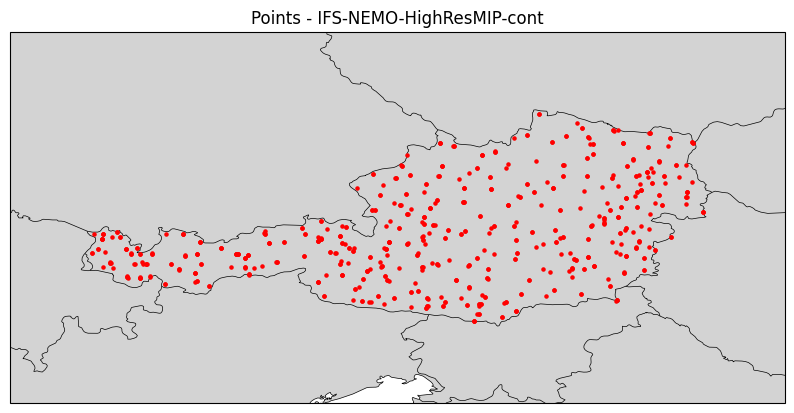

In [24]:
fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

ax.scatter(
    lons, lats,
    transform=ccrs.PlateCarree(),
    s=5, color="red", zorder=5
)

ax.set_extent([lons.min()-1, lons.max()+1, lats.min()-1, lats.max()+1])
plt.title("Points - IFS-NEMO-HighResMIP-cont")
plt.show()

### Write zarr store which gets finally populated with data

In [ ]:
import concurrent.futures
import xarray as xr
import os


scenario = scenarios.iloc[4]

scenario_ts = xr.Dataset()

store_path = f"./{scenario['model']}_{scenario['level type']}_{scenario['activity']}.zarr"
print(f"Data will be stored in: {store_path}")

with concurrent.futures.ThreadPoolExecutor(max_workers=20) as executor:
    futures = []
    for ind, station in geosphere_stations.iterrows():
    #for station in station_list:
        futures.append(executor.submit(get_station_data, geosphere_station=station, scenario=scenario))
    
    for future in concurrent.futures.as_completed(futures):
        if not os.path.exists(store_path):
            #scenario_ts = future.result().copy()
            future.result().chunk(chunks={"stationid": 1,
                              "latitude": 1,
                              "longitude": 1,
                              "levelist": 1,
                              "number": 1,
                              "datetime": 1,
                              "t": "auto"
                             }).to_zarr(store=store_path,
                        mode="w")
        else:
            #scenario_ts = xr.concat([scenario_ts, future.result()], dim="stationid")
            future.result().chunk(chunks={"stationid": 1,
                              "latitude": 1,
                              "longitude": 1,
                              "levelist": 1,
                              "number": 1,
                              "datetime": 1,
                              "t": "auto"
                             }).to_zarr(store=store_path,
                        append_dim="stationid")